# AI for Chemistry — Week 06, Session B
## Workshop: representation shoot-out — and the mini-project is assigned

**Course:** AI for Chemistry · **Session:** 06B (hands-on workshop, 2.0 h) ·
**Runtime:** < 15 s, no GPU.

### Suggested timing (solo study, ~120 min)

| Section | Topic | Time |
|--------:|-------|-----:|
| 0 | Setup: three representations of the same molecules | 10 min |
| 1 | Same model, three representations | 20 min |
| 2 | The full representation x model grid | 20 min |
| 3 | Chemical space, one map per representation | 15 min |
| 4 | Exercises (3) + mini-challenge | 30 min |
| 5 | **Mini-project assigned** | 25 min |

### Learning objectives
1. Run a representation shoot-out that holds the model fixed, to isolate the
   effect of representation choice from the effect of model choice. *(LO4, LO6)*
2. Read a representation × model comparison grid and explain patterns in it
   using Week 02-05 concepts (dimensionality, sparsity, dataset size). *(LO4, LO6)*
3. Compare chemical-space maps built from different representations of the
   same molecules. *(LO4, LO6)*
4. Understand the scope, required elements and rubric of the module's
   mini-project. *(LO8)*

### Prerequisites — before this notebook you should be able to
- Week 06A: the hand-engineered/learned representation spectrum.
- Week 03: the leaderboard pattern (fixed split, compare models).
- Week 02B: PCA on standardised features.

### How to use this notebook (solo study)
Read, run, check each **✅** cell in order. Section 5 is not code — it is the
module's mini-project brief; read it carefully. This is the **solutions**
notebook.


---
## 0. Setup: three representations of the same molecules

We featurise the (already cleaned) ESOL dataset three ways:

* **descriptors** — the 7 physicochemical numbers from Weeks 02-05.
* **MACCS keys** — a fixed, 166-bit "structural keys" fingerprint (each bit is
  a specific, human-nameable substructure, e.g. "has a ring of size 6") —
  smaller and more interpretable than Morgan, but coarser.
* **Morgan-2048** — the circular fingerprint from Week 02B.

**What to look for:** three feature matrices, all with **1117 rows** (the
same molecules, same order) but very different column counts: `7`, `167`,
`2048`.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from rdkit import Chem, RDLogger
from rdkit.Chem import Descriptors, rdFingerprintGenerator, MACCSkeys
from rdkit import DataStructs
RDLogger.DisableLog("rdApp.*")

from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error

RNG = np.random.default_rng(0xC0FFEE)

ROOT = Path.cwd()
while not (ROOT / "sources").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
DATA = ROOT / "sources" / "datasets"
FIGDIR = ROOT / "lectures" / "week-06_representations-inductive-bias" / "slides" / "figures"
FIGDIR.mkdir(parents=True, exist_ok=True)

TARGET = "measured log solubility in mols per litre"
esol = pd.read_csv(DATA / "esol_clean.csv")
mols = [Chem.MolFromSmiles(s) for s in esol["canonical_smiles"]]
y = esol[TARGET].to_numpy()

DESCRIPTORS = {
    "MolWt": Descriptors.MolWt, "MolLogP": Descriptors.MolLogP,
    "TPSA": Descriptors.TPSA, "NumHDonors": Descriptors.NumHDonors,
    "NumHAcceptors": Descriptors.NumHAcceptors,
    "NumRotatableBonds": Descriptors.NumRotatableBonds,
    "NumAromaticRings": Descriptors.NumAromaticRings,
}
Xdesc = np.array([[fn(m) for fn in DESCRIPTORS.values()] for m in mols], dtype=float)

Xmaccs = np.zeros((len(mols), 167), dtype=np.uint8)
for i, m in enumerate(mols):
    DataStructs.ConvertToNumpyArray(MACCSkeys.GenMACCSKeys(m), Xmaccs[i])

mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
Xfp = np.zeros((len(mols), 2048), dtype=np.uint8)
for i, m in enumerate(mols):
    fp = mfpgen.GetFingerprint(m)
    DataStructs.ConvertToNumpyArray(fp, Xfp[i])

REPRESENTATIONS = {"descriptors": Xdesc, "MACCS": Xmaccs, "Morgan-2048": Xfp}
for name, X in REPRESENTATIONS.items():
    print(f"{name:12s} shape {X.shape}")

idx = np.arange(len(mols))
idx_train, idx_test = train_test_split(idx, test_size=0.2, random_state=42)  # same as Week 03
y_train, y_test = y[idx_train], y[idx_test]


descriptors  shape (1117, 7)
MACCS        shape (1117, 167)
Morgan-2048  shape (1117, 2048)


> **Common errors — Setup**
> - Using a **different** train/test split per representation (e.g. calling
>   `train_test_split` three times on three different arrays) — always split
>   **indices** once and reuse them, exactly as Week 03B did for its
>   leaderboard.
> - MACCS bit 0 is unused by convention (a historical artefact of the
>   original key definitions) — harmless to include, but do not be alarmed if
>   it is always zero.


### ✅ Check yourself — Section 0

Prints `Section 0 OK`. Three representations, same 1117 molecules, column counts 7/167/2048.


In [2]:
# --- checkpoint (do not edit) ---
assert Xdesc.shape == (1117, 7)
assert Xmaccs.shape == (1117, 167)
assert Xfp.shape == (1117, 2048)
assert len(idx_train) == 893 and len(idx_test) == 224
print("Section 0 OK")


Section 0 OK


**Conceptual questions**


1. MACCS keys are described as "coarser" than Morgan fingerprints. What does
   that mean concretely, in terms of what a single bit represents?
2. Why must all three representations share the *same* train/test split to
   make Section 1's comparison meaningful?


**Answers**


1. Each MACCS bit corresponds to one specific, pre-defined substructure
   pattern from a fixed list of 166 — two chemically quite different
   molecules can share many MACCS bits if they happen to share those broad
   features, whereas Morgan's much larger bit space (2048, hashed from
   many possible local environments) can distinguish finer structural detail.
2. If the splits differed, any performance difference between
   representations could simply reflect "one representation happened to get
   an easier test set", not a genuine property of the representation —
   exactly Week 03B's fixed-split discipline, applied across representations
   instead of across models.


---
## 1. Same model, three representations

Hold the model **fixed** (random forest, the strongest single model from
Week 03B) and vary only the representation. This isolates what the
representation itself contributes.

**What to look for:** the small, dense **descriptor** block wins on this
~900-row dataset; the large, sparse **Morgan** fingerprint does worst of the
three, despite encoding far more structural detail in principle — echoing
Week 06A's "more learned/more complex is not automatically better at small
data scale" lesson.


In [3]:
def fit_and_score(X, model_fn, standardise=False):
    """Fit model_fn() on X[idx_train] and return test RMSE."""
    X_train, X_test = X[idx_train], X[idx_test]
    if standardise:
        scaler = StandardScaler().fit(X_train)
        X_train, X_test = scaler.transform(X_train), scaler.transform(X_test)
    model = model_fn().fit(X_train, y_train)
    return mean_squared_error(y_test, model.predict(X_test)) ** 0.5

rf_factory = lambda: RandomForestRegressor(n_estimators=300, random_state=0, n_jobs=-1)

rmse_by_representation = {
    name: fit_and_score(X, rf_factory) for name, X in REPRESENTATIONS.items()
}
for name, rmse in sorted(rmse_by_representation.items(), key=lambda kv: kv[1]):
    print(f"{name:12s} RMSE = {rmse:.3f}")


descriptors  RMSE = 0.769
MACCS        RMSE = 0.974
Morgan-2048  RMSE = 1.088


> **Common errors — Section 1**
> - Standardising the fingerprints (0/1 columns) the same way as the
>   continuous descriptor block — unnecessary, since random forests split on
>   raw thresholds regardless of scale; standardising is essential for Ridge
>   (Section 2) but not for tree-based models.
> - Concluding "fingerprints are bad" from this one result — Week 07 will
>   show a representation derived from the same molecular graph, learned end
>   to end, doing better; the fixed 2048-bit hash is not the ceiling for
>   graph-based information.


### ✅ Check yourself — Section 1

Prints `Section 1 OK`. Descriptors beat Morgan-2048 with the same model (random forest).


In [4]:
# --- checkpoint (do not edit) ---
assert set(rmse_by_representation) == {"descriptors", "MACCS", "Morgan-2048"}
assert rmse_by_representation["descriptors"] < rmse_by_representation["Morgan-2048"]
assert all(r > 0 for r in rmse_by_representation.values())
print("Section 1 OK")


Section 1 OK


**Conceptual questions**


1. This is exactly a Week 03-style leaderboard, but with representation as
   the varying axis instead of model type. What did we have to hold fixed to
   make that comparison fair?
2. Would you expect this ranking to hold on a dataset of 100,000 molecules
   instead of about 1,100?


**Answers**


1. The model (random forest, same hyperparameters), the train/test split, and
   the metric — varying only the representation, mirroring Week 03B's rule
   of changing one thing at a time.
2. Not necessarily — with far more training examples, the higher-dimensional
   fingerprint representation has more opportunity to have its rarer,
   individually-uninformative bits become useful in combination; the
   descriptors' advantage here is partly a **small-data** advantage (Week
   06A's inductive-bias trade-off), not an absolute one.


---
## 2. The full representation × model grid

Now vary **both** axes: 3 representations × 3 models (`Ridge`, `k`-nearest
neighbours, random forest) — 9 fits total. This shows whether representation
or model choice matters more, and whether they interact (a representation
that is bad for one model type can still be fine for another).

**What to look for:** random forest is the most robust model *across*
representations; `Ridge` and k-NN are much more sensitive to which
representation they are given (compare their Morgan-2048 row to their
descriptors row).


In [5]:
MODELS = {
    "Ridge": lambda: Ridge(alpha=1.0),
    "kNN (k=5)": lambda: KNeighborsRegressor(n_neighbors=5),
    "Random forest": rf_factory,
}

grid_rows = []
for rep_name, X in REPRESENTATIONS.items():
    for model_name, model_fn in MODELS.items():
        standardise = (model_name != "Random forest")   # trees do not need scaling
        rmse = fit_and_score(X, model_fn, standardise=standardise)
        grid_rows.append({"representation": rep_name, "model": model_name, "RMSE": rmse})

grid = pd.DataFrame(grid_rows)
grid_pivot = grid.pivot(index="representation", columns="model", values="RMSE")
grid_pivot = grid_pivot.reindex(index=["descriptors", "MACCS", "Morgan-2048"],
                                columns=["Ridge", "kNN (k=5)", "Random forest"])
grid_pivot.round(3)


model,Ridge,kNN (k=5),Random forest
representation,,,
descriptors,0.995,0.855,0.769
MACCS,1.241,1.233,0.974
Morgan-2048,2.129,1.937,1.088


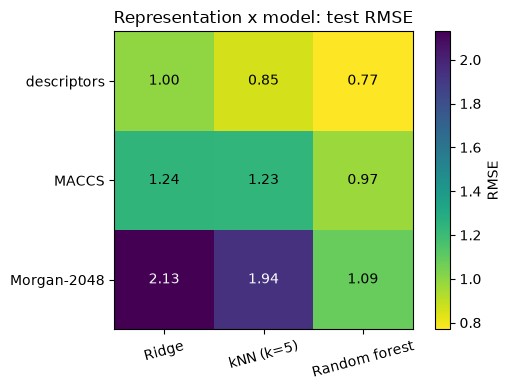

In [6]:
fig, ax = plt.subplots(figsize=(5.5, 4))
im = ax.imshow(grid_pivot.values, cmap="viridis_r")
ax.set_xticks(range(3)); ax.set_xticklabels(grid_pivot.columns, rotation=15)
ax.set_yticks(range(3)); ax.set_yticklabels(grid_pivot.index)
for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{grid_pivot.values[i, j]:.2f}", ha="center", va="center",
                color="w" if grid_pivot.values[i, j] > grid_pivot.values.mean() else "k")
ax.set_title("Representation x model: test RMSE")
fig.colorbar(im, label="RMSE")
fig.tight_layout(); fig.savefig(FIGDIR / "representation_shootout_grid.png", dpi=200)
plt.show()


> **Common errors — Section 2**
> - Reading only the row or column **totals/averages** and missing an
>   interaction — e.g. one model might be uniquely bad with one specific
>   representation for a reason neither margin reveals (Exercise 2 asks you
>   to quantify this directly).
> - Drawing a general conclusion ("random forests are always best") from a
>   9-cell grid on one ~1,100-molecule regression dataset — this is a
>   demonstration of the *method* of shooting out representations and models
>   together, not a universal ranking.


### ✅ Check yourself — Section 2

Prints `Section 2 OK`. A 3x3 grid; descriptors' best model beats Morgan-2048's best model.


In [7]:
# --- checkpoint (do not edit) ---
assert grid_pivot.shape == (3, 3)
assert grid_pivot.loc["descriptors"].min() < grid_pivot.loc["Morgan-2048"].min()
assert (FIGDIR / "representation_shootout_grid.png").is_file()
print("Section 2 OK")


Section 2 OK


**Conceptual questions**


1. Look at the `Ridge` column across the three representations. Does its
   pattern match the `Random forest` column's pattern?
2. If you only had budget to try **one** (representation, model) pair on a
   brand-new similar dataset, which would this grid suggest, and what caveat
   would you attach to that recommendation?


**Answers**


1. Not necessarily — `Ridge` typically degrades far more sharply on the
   high-dimensional, sparse Morgan-2048 representation than random forest
   does (Week 03B's $p\gg n$ overfitting regime hits linear models harder),
   illustrating a real representation x model interaction, not just two
   independent rankings.
2. **Descriptors + random forest**, based on this grid — but the caveat is
   that this is a small (~1,100-row), single-target regression dataset;
   different dataset sizes, targets or chemistries could change which
   representation/model pair wins (as discussed in Section 1's Question 2).


---
## 3. Chemical space, one map per representation

PCA (Week 02B) applied separately to each **standardised** representation,
coloured by measured solubility, shows how differently each one organises
the *same* molecules.

**What to look for:** the descriptor-based map (only 7 dimensions to start
from) shows the clearest colour gradient; the fingerprint-based maps are
messier — high-dimensional, sparse, binary data does not compress into 2
principal components as cleanly (Week 02B saw the same effect).


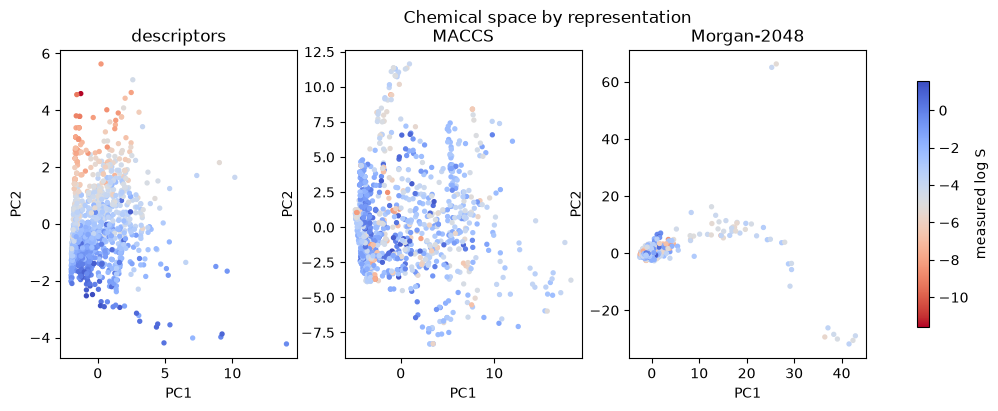

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (name, X) in zip(axes, REPRESENTATIONS.items()):
    Xstd = StandardScaler().fit_transform(X.astype(float))
    Z = PCA(n_components=2, random_state=0).fit_transform(Xstd)
    sc = ax.scatter(Z[:, 0], Z[:, 1], c=y, cmap="coolwarm_r", s=8)
    ax.set_title(name); ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
fig.colorbar(sc, ax=axes, label="measured log S", shrink=0.8)
fig.suptitle("Chemical space by representation")
fig.savefig(FIGDIR / "chemical_space_by_representation.png", dpi=200)
plt.show()


> **Common errors — Section 3**
> - Comparing PC1/PC2 **positions** across the three panels as if they meant
>   the same thing — each PCA is fit independently, so axis directions and
>   scales are unrelated between panels; only the *pattern* (how cleanly
>   colour separates) is comparable.


### ✅ Check yourself — Section 3

Prints `Section 3 OK`. Three PCA panels, one per representation.


In [9]:
# --- checkpoint (do not edit) ---
assert (FIGDIR / "chemical_space_by_representation.png").is_file()
print("Section 3 OK")


Section 3 OK


**Conceptual questions**


1. Why is comparing PC1 in the descriptor panel to PC1 in the Morgan panel
   not meaningful?
2. What would you look for in these maps if you suspected the dataset had an
   outlier molecule contaminating the descriptor block (e.g. a data-entry
   error giving an impossible molecular weight)?


**Answers**


1. Each PCA maximises variance **within its own representation** independently
   — the two PC1 axes are different linear combinations of entirely
   different underlying features, related only in that both are "the
   direction of greatest variance for that representation".
2. A single point sitting far outside the main cloud in the descriptor panel
   (but not necessarily in the fingerprint panels, since a data-entry error in
   a descriptor would not necessarily corrupt the structural fingerprint) —
   exactly the kind of visual outlier check Week 02B's chemical-space section
   introduced.


---
## 4. Exercises


### Exercise 1 — add a fourth representation: concatenation *(easy, ~12 min)*

Write `concatenate_representations(*Xs)` using `np.hstack`, build
`Xconcat = concatenate_representations(Xdesc, Xfp)` (standardise `Xdesc`
first, leave `Xfp` as 0/1), and score it with random forest. Does
concatenation beat the best single representation from Section 1?

<details><summary>Show hint</summary>

`np.hstack([StandardScaler().fit_transform(Xdesc), Xfp])`; then reuse
`fit_and_score(Xconcat, rf_factory)`.
</details>


In [10]:
def concatenate_representations(*Xs):
    """Column-wise concatenation of several feature matrices."""
    return np.hstack(Xs)

Xconcat = concatenate_representations(StandardScaler().fit_transform(Xdesc), Xfp)
rmse_concat = fit_and_score(Xconcat, rf_factory)
print(f"concat(descriptors, Morgan-2048) + RF: RMSE = {rmse_concat:.3f}")
print(f"best single representation: {min(rmse_by_representation.values()):.3f}")


concat(descriptors, Morgan-2048) + RF: RMSE = 0.768
best single representation: 0.769


In [11]:
# --- check your answer (do not edit) ---
assert Xconcat.shape == (1117, 7 + 2048)
assert rmse_concat > 0
print("Exercise 1 OK")


Exercise 1 OK


### Exercise 2 — quantify the representation x model interaction *(medium, ~15 min)*

Write `interaction_strength(grid_pivot)` returning, for each model (column),
the **range** (max - min) of RMSE across representations. A larger range
means that model's performance depends more on representation choice.

<details><summary>Show hint</summary>

`grid_pivot.max(axis=0) - grid_pivot.min(axis=0)` gives one range per model
column directly.
</details>


In [12]:
def interaction_strength(grid_pivot):
    """Range (max-min) of RMSE across representations, for each model column."""
    return grid_pivot.max(axis=0) - grid_pivot.min(axis=0)

spread = interaction_strength(grid_pivot)
print(spread.sort_values(ascending=False).round(3))


model
Ridge            1.134
kNN (k=5)        1.082
Random forest    0.319
dtype: float64


In [13]:
# --- check your answer (do not edit) ---
assert len(spread) == 3
assert spread["Random forest"] < spread["Ridge"]
print("Exercise 2 OK")


Exercise 2 OK


### Exercise 3 — MACCS vs Morgan: same model family, different granularity *(medium, ~15 min)*

Write `bit_overlap_report(Xa, Xb, name_a, name_b)` returning a dict with each
matrix's dimensionality and mean bits-set-per-molecule. Compare `Xmaccs` and
`Xfp` and connect the numbers to Section 0's "coarser vs finer" discussion.

<details><summary>Show hint</summary>

`X.sum(axis=1).mean()` gives the mean number of set bits per row.
</details>


In [14]:
def bit_overlap_report(Xa, Xb, name_a, name_b):
    """Dimensionality and mean bits-set for two binary fingerprint matrices."""
    return {
        name_a: {"n_bits": Xa.shape[1], "mean_bits_set": Xa.sum(axis=1).mean()},
        name_b: {"n_bits": Xb.shape[1], "mean_bits_set": Xb.sum(axis=1).mean()},
    }

report = bit_overlap_report(Xmaccs, Xfp, "MACCS", "Morgan-2048")
print(report)


{'MACCS': {'n_bits': 167, 'mean_bits_set': np.float64(23.54700089525515)}, 'Morgan-2048': {'n_bits': 2048, 'mean_bits_set': np.float64(21.475380483437778)}}


In [15]:
# --- check your answer (do not edit) ---
assert report["MACCS"]["n_bits"] == 167
assert report["Morgan-2048"]["n_bits"] == 2048
assert report["MACCS"]["mean_bits_set"] > 0 and report["Morgan-2048"]["mean_bits_set"] > 0
print("Exercise 3 OK")


Exercise 3 OK


### 🏁 Mini-challenge — beat every single representation *(~20 min)*

Section 1 found the best single (representation, random forest) pair.
Exercise 1 tried concatenation. Now search a **weighted blend of
predictions** instead of a blend of features: train separate random forests
on `descriptors` and `Morgan-2048`, and average their predictions with a
tunable weight.

Write `best_blend_weight(pred_a, pred_b, y_true, weights)` that, for each
`w` in `weights`, scores `w*pred_a + (1-w)*pred_b` against `y_true` and
returns `(best_w, best_rmse)`.


Implement `best_blend_weight` and find the best blend of the descriptor and
Morgan-2048 random forests.


In [16]:
def best_blend_weight(pred_a, pred_b, y_true, weights):
    """(best_w, best_rmse) for blended predictions w*pred_a + (1-w)*pred_b."""
    best_w, best_rmse = None, float("inf")
    for w in weights:
        blended = w * pred_a + (1 - w) * pred_b
        rmse = mean_squared_error(y_true, blended) ** 0.5
        if rmse < best_rmse:
            best_w, best_rmse = w, rmse
    return best_w, best_rmse

rf_desc = rf_factory().fit(Xdesc[idx_train], y_train)
rf_fp = rf_factory().fit(Xfp[idx_train], y_train)
pred_desc = rf_desc.predict(Xdesc[idx_test])
pred_fp = rf_fp.predict(Xfp[idx_test])

best_w, best_blend_rmse = best_blend_weight(pred_desc, pred_fp, y_test, np.linspace(0, 1, 11))
print(f"best blend weight (descriptors): {best_w:.1f}  RMSE = {best_blend_rmse:.3f}")
print(f"descriptors-only RMSE: {rmse_by_representation['descriptors']:.3f}")


best blend weight (descriptors): 0.8  RMSE = 0.730
descriptors-only RMSE: 0.769


In [17]:
# --- check your answer (do not edit) ---
assert 0.0 <= best_w <= 1.0
assert best_blend_rmse <= rmse_by_representation["descriptors"] + 1e-9
print("Mini-challenge OK")


Mini-challenge OK


---
## Summary — what you learned

- A **representation shoot-out** holds the model fixed to isolate what the
  representation contributes; a **representation x model grid** shows the two
  choices can interact.
- On this ~1,100-row regression task, the small, dense descriptor block beats
  Morgan-2048, and random forest is the most representation-robust model —
  neither is a universal law, both are dataset-scale-dependent findings.
- Chemical-space maps built from different representations of the same
  molecules can look qualitatively different.
- Blending predictions from different representations (mini-challenge) is
  another way to combine representations, alongside Exercise 1's feature
  concatenation.


---
## 5. 📋 Mini-project assigned

This week's workshop closes the classical-ML half of the course
(Weeks 01-06) and opens the module's own applied research task: a small,
end-to-end study on a chemical dataset, using exactly the workflow built over
the last six weeks.

**Read the full brief now:** [`assessments/mini-project-brief.md`](../../../assessments/mini-project-brief.md)

In short, you will:

1. **Choose a dataset** — a new task on a cached course dataset, an
   unused MoleculeNet dataset (checksum-pinned yourself, as this course's own
   dataset scripts do), or your own (with approval).
2. **Apply the full pipeline**: data hygiene (Week 02/04) → at least two
   representations (Week 02/06) → a baseline plus at least two models
   (Week 03/04) → both a random **and** a structure-aware split (Week 02B/03B)
   → metrics appropriate to the task (Week 03A/04) → error analysis (Week 04B)
   → one stated limitation.
3. **Present** in Week 10's mini-project hackathon session.

Everything from Week 07 onward (GNNs, sequence models, generative models,
XAI) is **optional extension** for the mini-project, not required — do the
required elements rigorously first.

> `TODO(verify)` — the brief's exact weighting, group-size policy and
> submission format are drafted from the syllabus and need instructor
> sign-off; do not treat the numbers in the brief as final until confirmed.


## Further reading (course source list only)

- DeepChem, *An Introduction to MoleculeNet* (representation-comparison
  framing; the source for the "hold the model fixed, vary the featurizer"
  idea used in Sections 1-2):
  <https://github.com/deepchem/deepchem/blob/master/examples/tutorials/An_Introduction_To_MoleculeNet.ipynb>


## Attribution

Original teaching material for *AI for Chemistry*, adapted and rewritten from:

- **DeepChem**, *An Introduction to MoleculeNet* — the idea of comparing
  representations with the model held fixed; **reproduced here with RDKit +
  scikit-learn directly** rather than DeepChem's own featurizers, to avoid
  adding the `deepchem` package (and its own deep-learning-framework
  constraints) to `env/environment.yml`. MIT licence.
  <https://github.com/deepchem/deepchem>

Continues the ESOL dataset from Weeks 02-03/05 and the representation
spectrum from Week 06A. No verbatim text is reproduced from the sources
above.
